In [ ]:
pip install nbformat

In [ ]:
%run DLS_functions+metrics.ipynb

## Imports

In [ ]:
import pandas as pd
import os
import csv
from pathlib import Path

# DLS Data

## Round 1

In [ ]:
BASE_DIR = os.getcwd()

file_path = os.path.join(
    BASE_DIR,
    "Rawdata",
    "DesignExpert_results_round1_rawdata.csv"
)

df_DE_round1 = pd.read_csv(file_path)

#charg the data usign ";" as delimiter, and it loads it into the list "data"
with open(file_path, newline="", encoding="utf-8") as f:
    reader = csv.reader(f, delimiter=";")
    data = list(reader)

# Stores data
header = data[1]
rows = data[0:]
columns = list(zip(*rows)) #transpses the data (zip(rows)) to convert rows into columns


In [ ]:
## Creates Collection
Design_Expert_Sampling_Round1 = Collection("Design_Expert_Sampling_Round1")
print(Design_Expert_Sampling_Round1)

In [ ]:
## Creates Experiments. This is the loop that iterates through the columns and adds each experiment to the created collection. 
for col in columns[1:]:
    if col[0] != '': 
        Design_Expert_Sampling_Round1.add_experiment(col[0], debug=0)
print(df_DE_round1)

In [ ]:
## Adds Replicas to Corresponding Experiment
# For each column of data, identify the experiment name, replica name, and the data for the x and y axes.
# Then, find the corresponding experiment and add the data to the previously created collection.
for col in columns[1:]:
    exp_name = col[0]
    rep_name = col[2]
    x_data   = columns[0][3:]
    y_data   = col[3:]
    found, experiment = Design_Expert_Sampling_Round1.find_experiment(rep_name, debug=0)
    if found: experiment.add_replica(rep_name, x_data, y_data, debug=0)
    else: print(f"Experiment {col[1]} not found")

### Review data and fitting

In [43]:
## Fitting parameters. These are used to represent the 'ideal' distribution
mu_bounds    = [1.7,4]   ## In logarithmic scale 10^1.7 = 50; 10^4 = 10000
#search for the center of the distribution between 1.7 and 4. The algorithm will only search for results within these limits

for exp in Design_Expert_Sampling_Round1.experiments:
    for rep in exp.replicas:
        rep.fit_data(mu_bounds=mu_bounds, debug=0) # comparison of the real data with an "ideal" distribution and calculation of the distance
        print(exp.name, rep.name, rep.distance)

AFO-008(2) R1.008(2) 0.1476
AFO-008(2) R2.008(2) 0.2872
AFO-008(2) R3.008(2) 0.7821
ERM-334(2) R1.334(2) 0.5515
ERM-334(2) R2.334(2) 0.5455
ERM-334(2) R3.334(2) 0.6776
ERM-335 R1.335 0.2735
ERM-335 R2.335 0.2804
ERM-335 R3.335 0.2719
AFO-010 R1.010 0.1961
AFO-010 R2.010 0.2271
AFO-010 R3.010 0.1995
AFO-011 R1.011 0.2131
AFO-011 R2.011 0.1856
AFO-011 R3.011 0.143
AFO-012 R1.012 0.1059
AFO-012 R2.012 0.1376
AFO-012 R3.012 0.1605
ERM-339 R1.339 0.2281
ERM-339 R2.339 0.2676
ERM-339 R3.339 0.2222
ERM-340 R1.340 0.133
ERM-340 R2.340 0.1072
ERM-340 R3.340 0.1362
AFO-015(1) R1.015(1) 0.183
AFO-015(1) R2.015(1) 0.2322
AFO-015(1) R3.015(1) 0.181
AFO-015(2) R1.015(2) 0.2131
AFO-015(2) R2.015(2) 0.1694
AFO-015(2) R3.015(2) 0.1614
ERM-343 R1.343 35.3803
ERM-343 R2.343 33.7575
ERM-343 R3.343 35.7242
ERM-263 R1.263 0.4077
ERM-263 R2.263 0.3695
ERM-263 R3.263 0.2862
AFO-018(1) R1.018(1) 0.155
AFO-018(1) R2.018(1) 0.1767
AFO-018(1) R3.018(1) 0.215
AFO-018(2) R1.018(2) 0.2513
AFO-018(2) R2.018(2) 0.1755

In [44]:
#Mean distance values of the three replicates of each sample      
for exp in Design_Expert_Sampling_Round1.experiments:
    print(exp.name, exp.distance)

AFO-008(2) 0.4056
ERM-334(2) 0.5915
ERM-335 0.2753
AFO-010 0.2076
AFO-011 0.1806
AFO-012 0.1347
ERM-339 0.2393
ERM-340 0.1255
AFO-015(1) 0.1987
AFO-015(2) 0.1813
ERM-343 34.954
ERM-263 0.3545
AFO-018(1) 0.1822
AFO-018(2) 0.1983
AFO-019 7.2
ERM-346 32.266
AFO-021 25.4875
AFO-022 0.2099


### Plot visualization

### Experiments

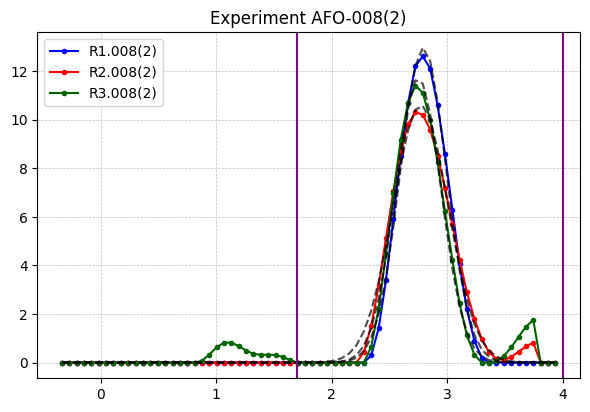

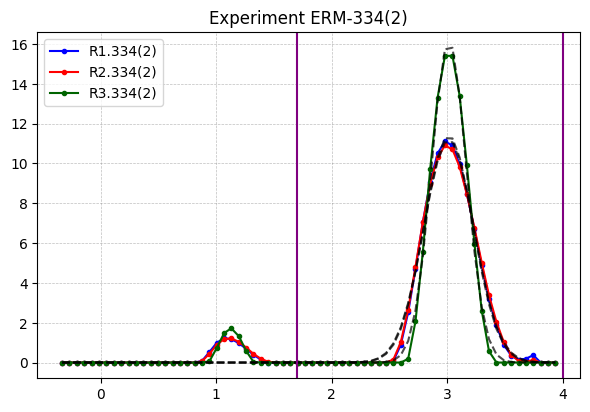

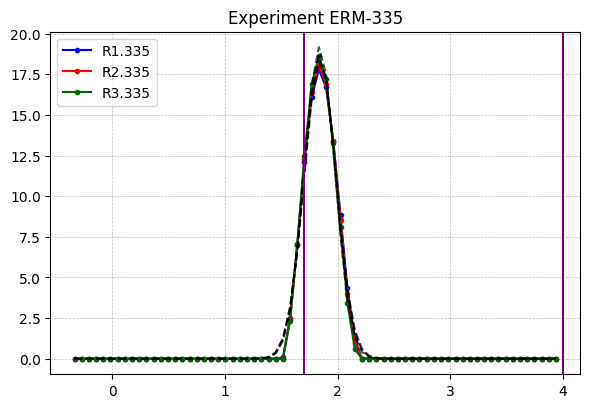

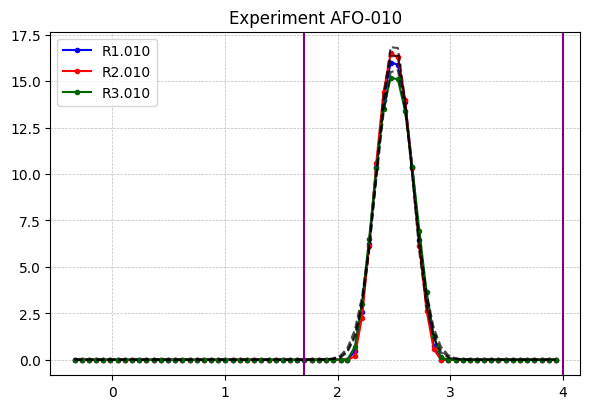

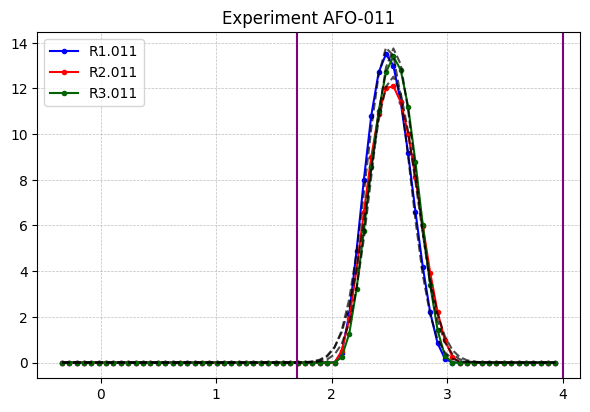

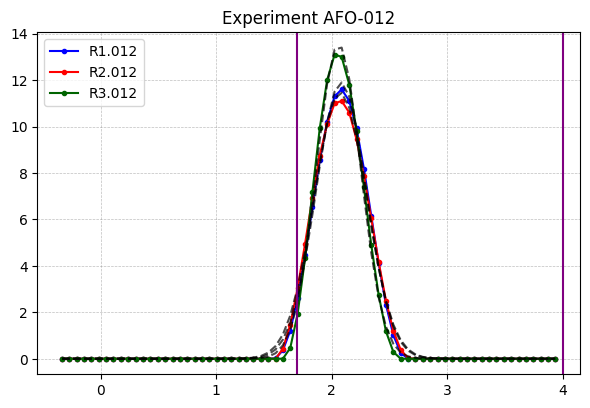

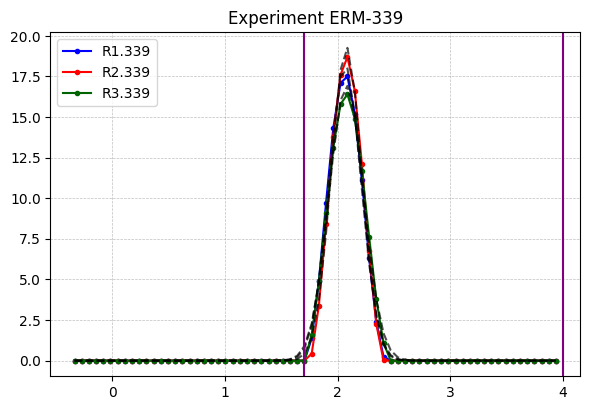

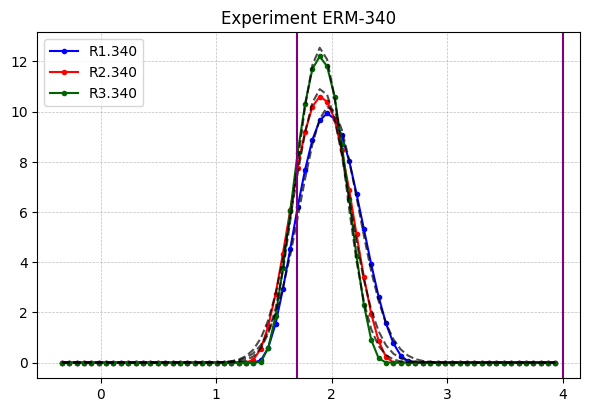

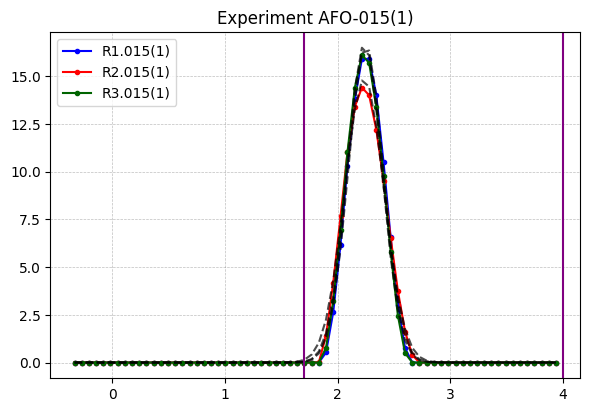

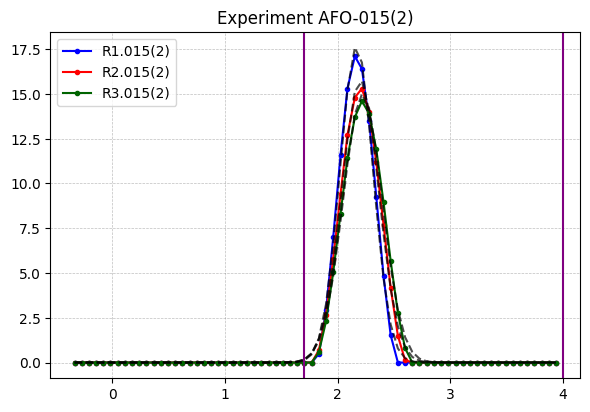

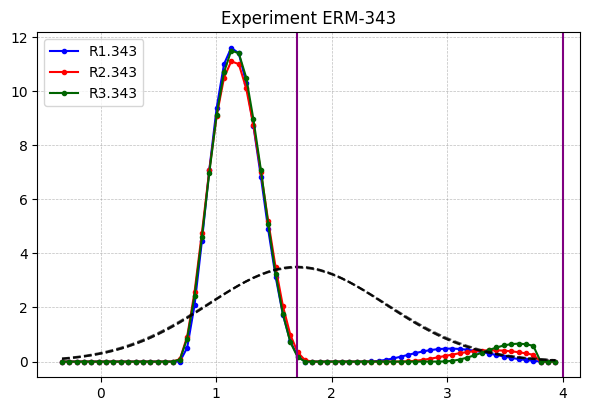

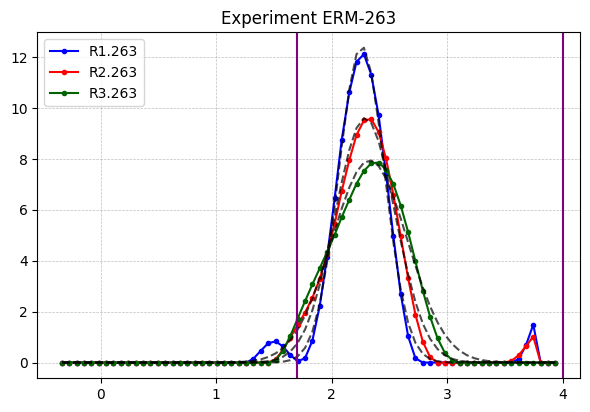

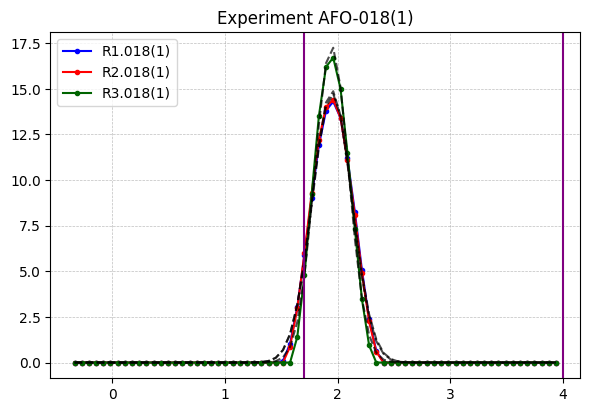

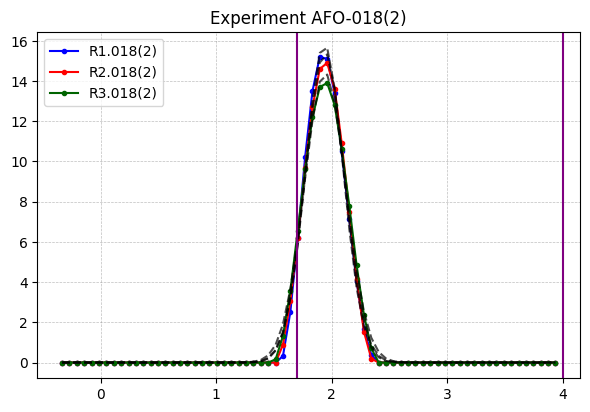

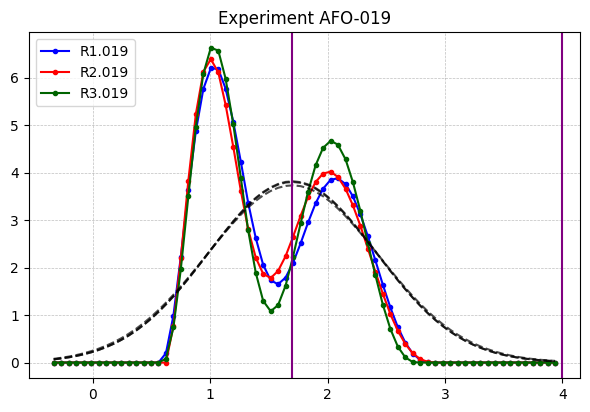

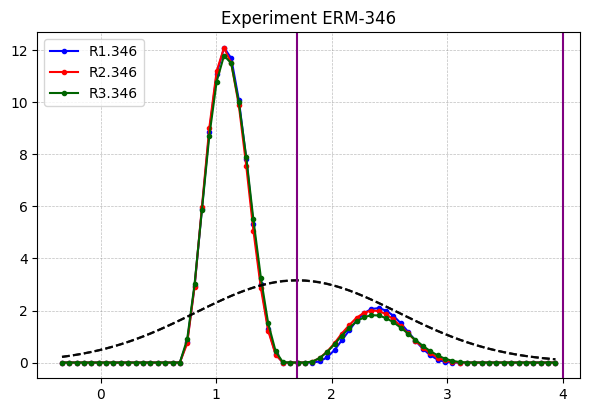

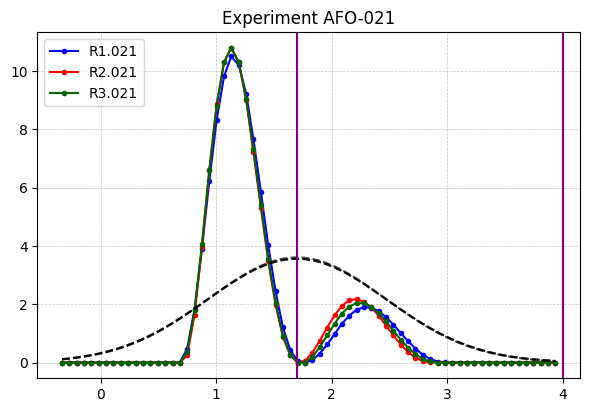

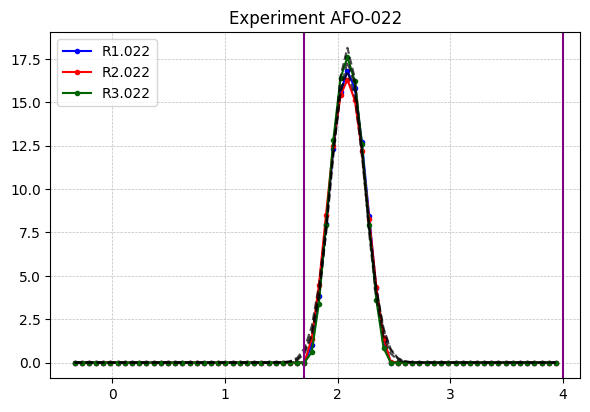

In [42]:
for exp in Design_Expert_Sampling_Round1.experiments:

    for rep in exp.replicas:
        if not hasattr(rep, "fitted_data"):
            rep.fit_data()

    log_x = exp.replicas[0].log_x_data

    y_all = np.array([rep.y_data for rep in exp.replicas])

    fit_all = np.vstack([rep.fitted_data for rep in exp.replicas])

    fig, ax = plot_(log_x, y_all, fit_all)

    #legend
    lines = ax.get_lines()

    n_rep = len(exp.replicas)
    
    for i in range(n_rep):
        lines[i].set_label(exp.replicas[i].name)

    ax.legend()

    mu_bounds = exp.replicas[0].mu_bounds
    ax.axvline(mu_bounds[0], c="purple")
    ax.axvline(mu_bounds[-1], c="purple")

    ax.set_title(f"Experiment {exp.name}")

    plt.show()

#### Replicates of individual experiments

In [ ]:
## Visual analysis
# A specific experiment is searched for and executed to generate a plot and see how the data behaves with respect to the ideal

found, debug_exp = Design_Expert_Sampling_Round1.find_experiment("ERM-343")
print(found)
print(debug_exp)

for rep in debug_exp.replicas:
    print(rep)
    rep.plot_fit()

In [ ]:
##Saves all the data (complete collection with information of the experiments and replicates) in a .npy file
#save_binary(Design_Expert_Sampling_Round1, "./Design_Expert_Sampling_Round1.npy")

##Loads the data from the .npy file and stores it in a variable if needed
#Design_Expert_Sampling_Round1_loaded = load_binary("./Design_Expert_Sampling_Round1.npy")
#print(Design_Expert_Sampling_Round1)

## Round 2

In [ ]:
BASE_DIR = os.getcwd()

file_path = os.path.join(
    BASE_DIR,
    "Rawdata",
    "DesignExpert_results_round2_rawdata.csv"
)

df_DE_round2 = pd.read_csv(file_path)

#charg the data usign ";" as delimiter, and it loads it into the list "data"
with open(file_path, newline="", encoding="utf-8") as f:
    reader = csv.reader(f, delimiter=";")
    data = list(reader)

# Stores data
header = data[1]
rows = data[0:]
columns = list(zip(*rows)) #transpses the data (zip(rows)) to convert rows into columns


In [ ]:
## Creates Collection
Design_Expert_Sampling_Round2 = Collection("Design_Expert_Sampling_Round2")
print(Design_Expert_Sampling_Round2)

In [ ]:
## Creates Experiments. This is the loop that iterates through the columns and adds each experiment to the created collection. 
for col in columns[1:]:
    if col[0] != '': 
        Design_Expert_Sampling_Round2.add_experiment(col[0], debug=0)
print(df_DE_round2)

In [ ]:
## Adds Replicas to Corresponding Experiment
# For each column of data, identify the experiment name, replica name, and the data for the x and y axes.
# Then, find the corresponding experiment and add the data to the previously created collection.
for col in columns[1:]:
    exp_name = col[0]
    rep_name = col[2]
    x_data   = columns[0][3:]
    y_data   = col[3:]
    found, experiment = Design_Expert_Sampling_Round2.find_experiment(rep_name, debug=0)
    if found: experiment.add_replica(rep_name, x_data, y_data, debug=0)
    else: print(f"Experiment {col[1]} not found")

### Review data and fitting

In [ ]:
## Fitting parameters. These are used to represent the 'ideal' distribution
mu_bounds    = [1.7,4]   ## In logarithmic scale 10^1.7 = 50; 10^4 = 10000
#search for the center of the distribution between 1.7 and 4. The algorithm will only search for results within these limits

for exp in Design_Expert_Sampling_Round2.experiments:
    for rep in exp.replicas:
        rep.fit_data(mu_bounds=mu_bounds, debug=0) # comparison of the real data with an "ideal" distribution and calculation of the distance
        print(exp.name, rep.name, rep.distance)

In [46]:
#Mean distance values of the three replicates of each sample      
for exp in Design_Expert_Sampling_Round2.experiments:
    print(exp.name, exp.distance)

ERM-397(1) 0.2316
ERM-397(2) 0.2772
ERM-398(1) 0.2687
ERM-398(2) 0.2316
ERM-399(1) 0.2644
ERM-399(2) 0.2575
ERM-400 0.2621
ERM-401 0.2468
ERM-402 0.1818
ERM-403 37.1851


### Plot visualization

#### Experiments

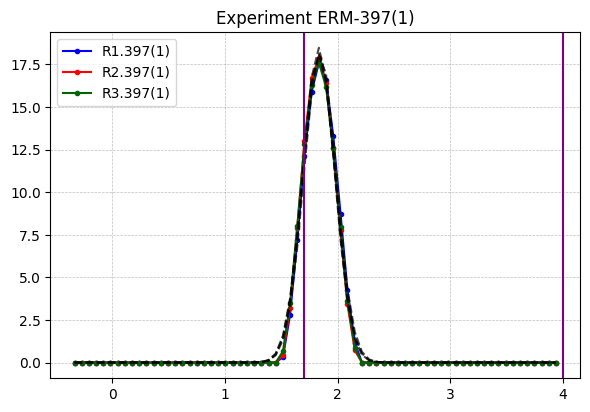

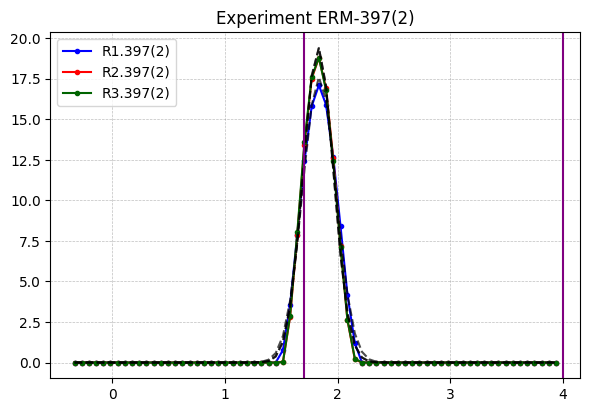

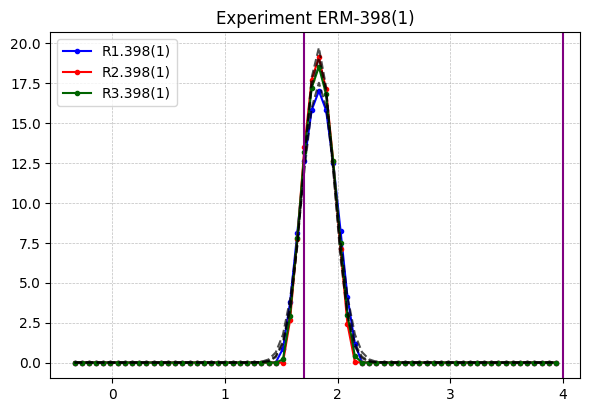

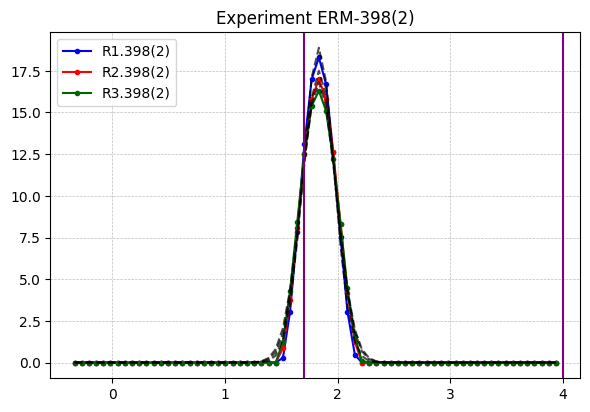

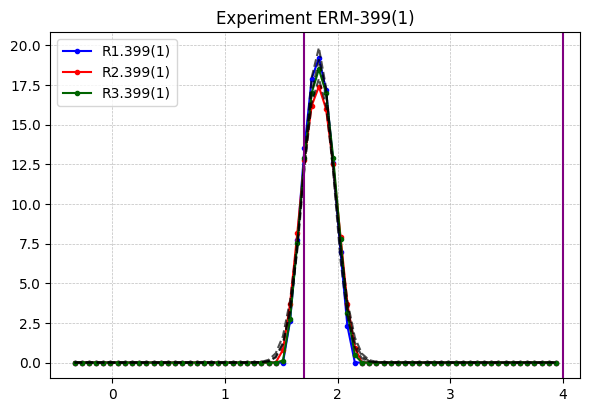

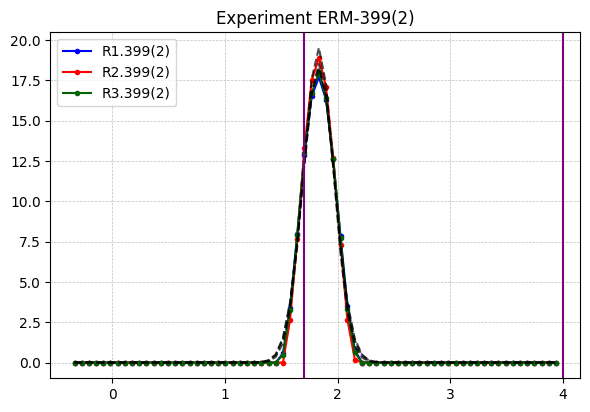

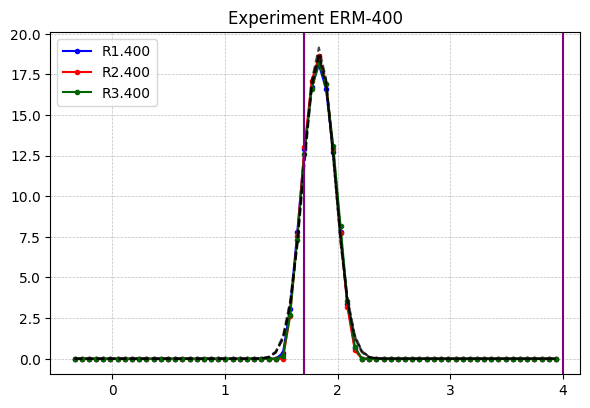

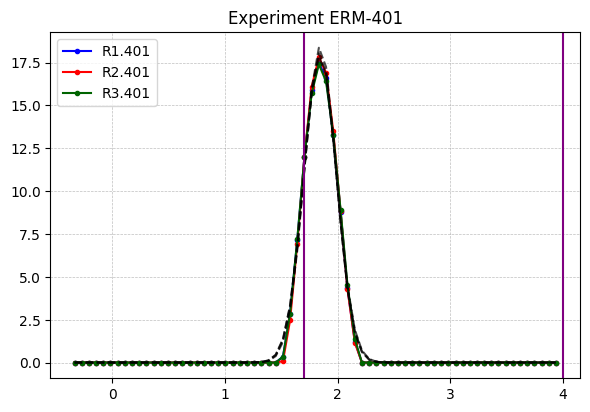

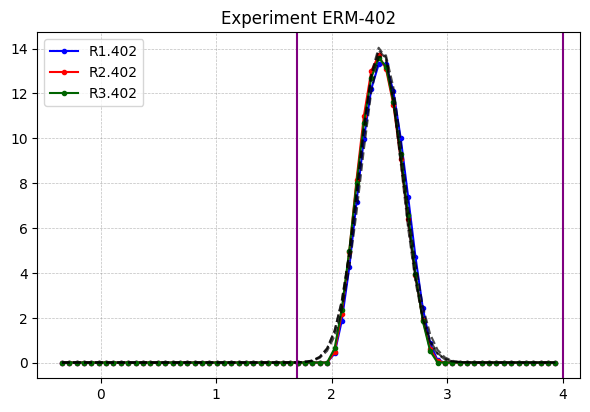

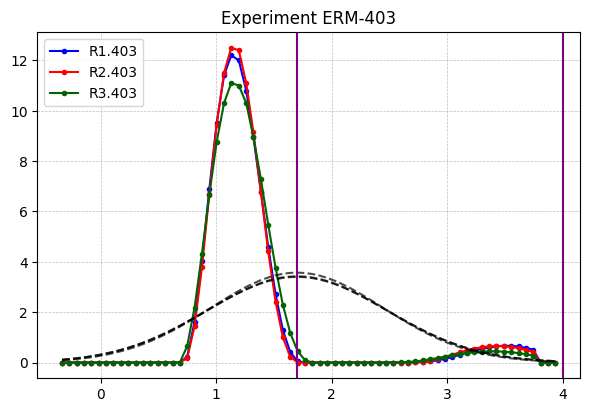

In [45]:
for exp in Design_Expert_Sampling_Round2.experiments:

    for rep in exp.replicas:
        if not hasattr(rep, "fitted_data"):
            rep.fit_data()

    log_x = exp.replicas[0].log_x_data

    y_all = np.array([rep.y_data for rep in exp.replicas])

    fit_all = np.vstack([rep.fitted_data for rep in exp.replicas])

    fig, ax = plot_(log_x, y_all, fit_all)

    #legend
    lines = ax.get_lines()

    n_rep = len(exp.replicas)
    
    for i in range(n_rep):
        lines[i].set_label(exp.replicas[i].name)

    ax.legend()

    mu_bounds = exp.replicas[0].mu_bounds
    ax.axvline(mu_bounds[0], c="purple")
    ax.axvline(mu_bounds[-1], c="purple")

    ax.set_title(f"Experiment {exp.name}")

    plt.show()

#### Replicates

In [ ]:
## Visual analysis
# A specific experiment is searched for and executed to generate a plot and see how the data behaves with respect to the ideal

found, debug_exp = Design_Expert_Sampling_Round2.find_experiment("ERM-403")
print(found)
print(debug_exp)

for rep in debug_exp.replicas:
    print(rep)
    rep.plot_fit()

In [ ]:
##Saves all the data (complete collection with information of the experiments and replicates) in a .npy file
#save_binary(Design_Expert_Sampling_Round1, "./Design_Expert_Sampling_Round1.npy")

##Loads the data from the .npy file and stores it in a variable if needed
#Design_Expert_Sampling_Round1_loaded = load_binary("./Design_Expert_Sampling_Round1.npy")
#print(Design_Expert_Sampling_Round1)

## Round 3

In [ ]:
BASE_DIR = os.getcwd()

file_path = os.path.join(
    BASE_DIR,
    "Rawdata",
    "DesignExpert_results_round3_rawdata.csv"
)

df_DE_round3 = pd.read_csv(file_path)

#charg the data usign ";" as delimiter, and it loads it into the list "data"
with open(file_path, newline="", encoding="utf-8") as f:
    reader = csv.reader(f, delimiter=";")
    data = list(reader)

# Stores data
header = data[1]
rows = data[0:]
columns = list(zip(*rows)) #transpses the data (zip(rows)) to convert rows into columns


In [ ]:
## Creates Collection
Design_Expert_Sampling_Round3 = Collection("Design_Expert_Sampling_Round3")
print(Design_Expert_Sampling_Round3)

In [ ]:
## Creates Experiments. This is the loop that iterates through the columns and adds each experiment to the created collection. 
for col in columns[1:]:
    if col[0] != '': 
        Design_Expert_Sampling_Round3.add_experiment(col[0], debug=0)
print(df_DE_round3)

In [ ]:
## Adds Replicas to Corresponding Experiment
# For each column of data, identify the experiment name, replica name, and the data for the x and y axes.
# Then, find the corresponding experiment and add the data to the previously created collection.
for col in columns[1:]:
    exp_name = col[0]
    rep_name = col[2]
    x_data   = columns[0][3:]
    y_data   = col[3:]
    found, experiment = Design_Expert_Sampling_Round3.find_experiment(rep_name, debug=0)
    if found: experiment.add_replica(rep_name, x_data, y_data, debug=0)
    else: print(f"Experiment {col[1]} not found")

### Review data and fitting

In [ ]:
## Fitting parameters. These are used to represent the 'ideal' distribution
mu_bounds    = [1.7,4]   ## In logarithmic scale 10^1.7 = 50; 10^4 = 10000
#search for the center of the distribution between 1.7 and 4. The algorithm will only search for results within these limits

for exp in Design_Expert_Sampling_Round3.experiments:
    for rep in exp.replicas:
        rep.fit_data(mu_bounds=mu_bounds, debug=0) # comparison of the real data with an "ideal" distribution and calculation of the distance
        print(exp.name, rep.name, rep.distance)

In [49]:
#Mean distance values of the three replicates of each sample      
for exp in Design_Expert_Sampling_Round3.experiments:
    print(exp.name, exp.distance)

ERM-423 0.2199
ERM-424 0.2476
ERM-425(1) 0.2602
ERM-425(2) 0.2888
ERM-426 0.2382
ERM-427(1) 0.2848
ERM-427(2) 0.2639
ERM-428 0.2599
ERM-429(1) 0.2876
ERM-429(2) 0.2225
ERM-430 0.2331
ERM-431 0.5299
ERM-432(1) 7.3664
ERM-432(2) 0.1796
ERM-433 21.1486


### Plot visualization

#### Experiments

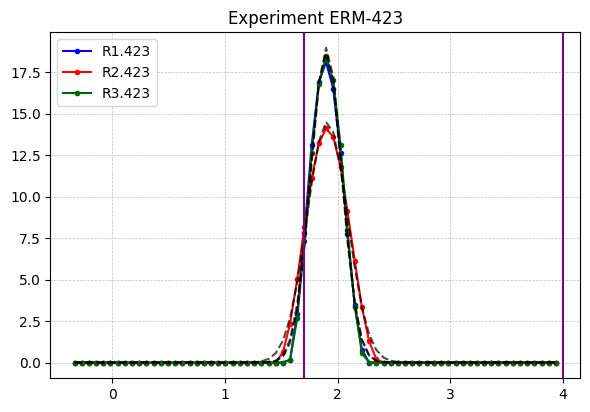

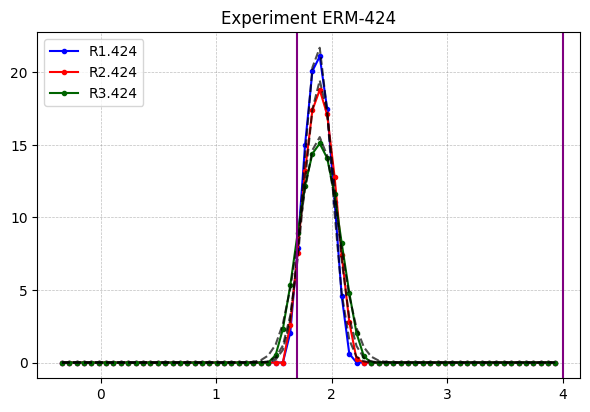

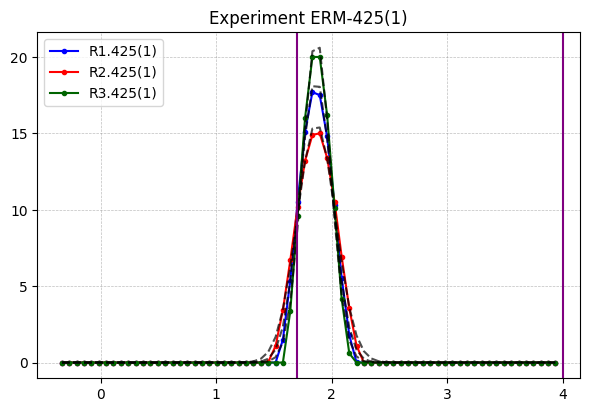

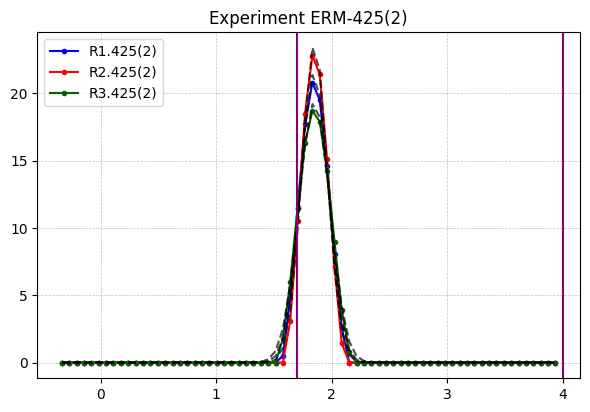

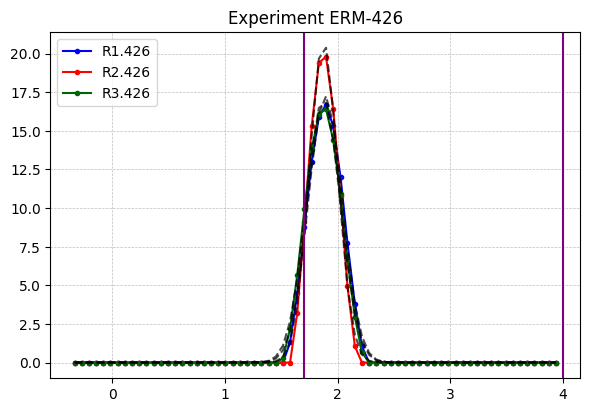

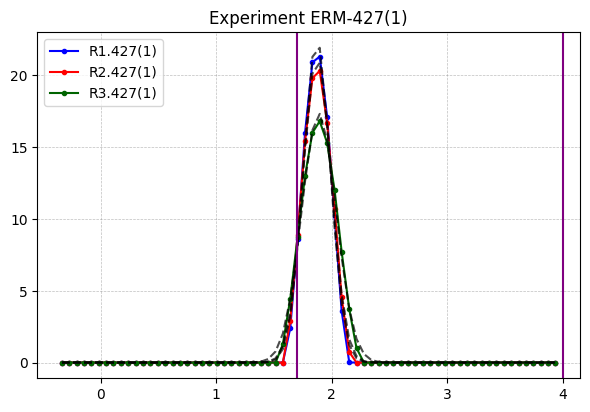

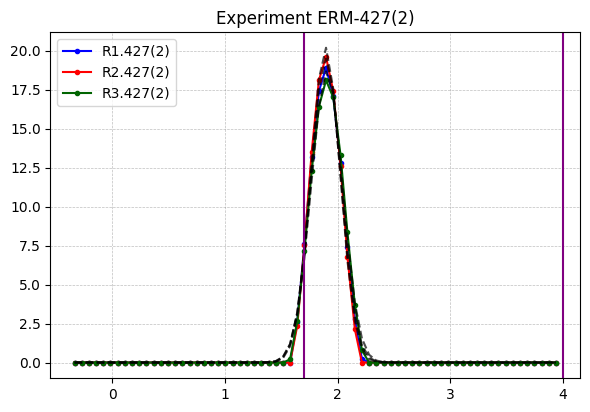

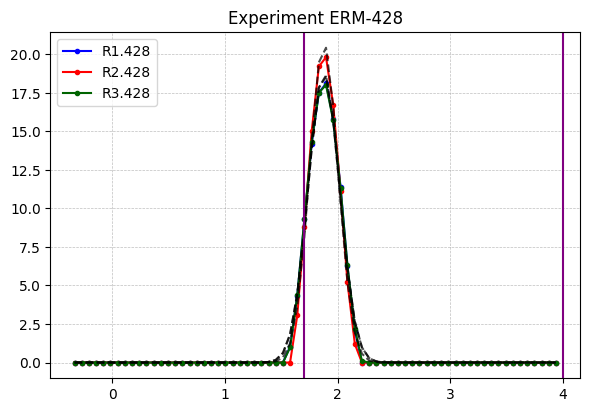

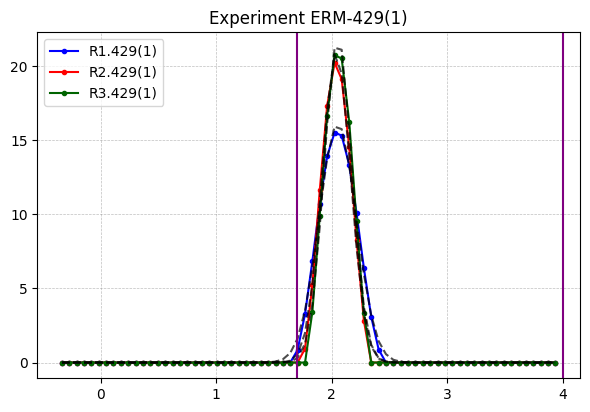

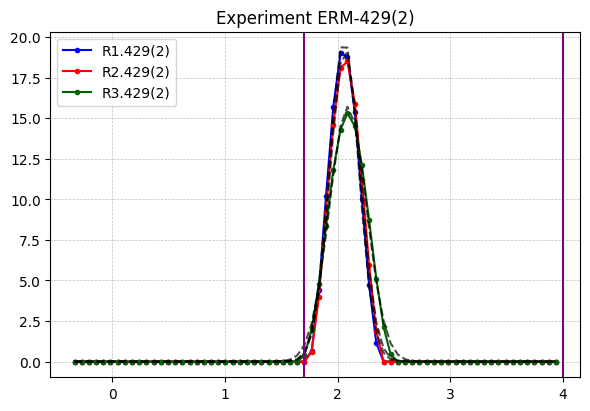

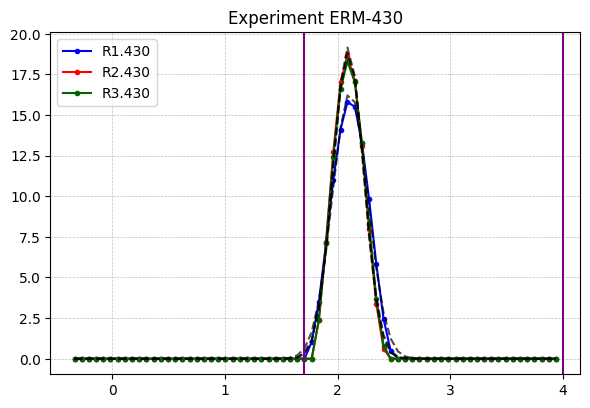

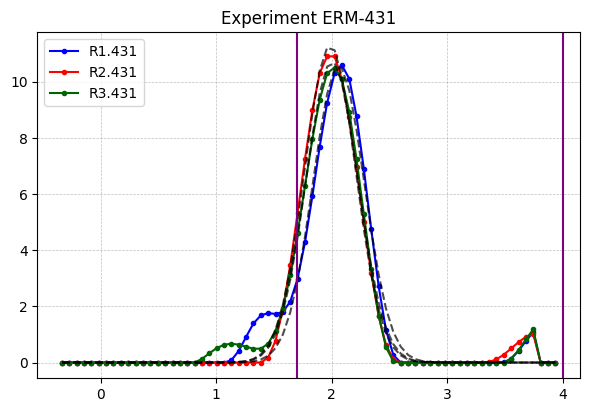

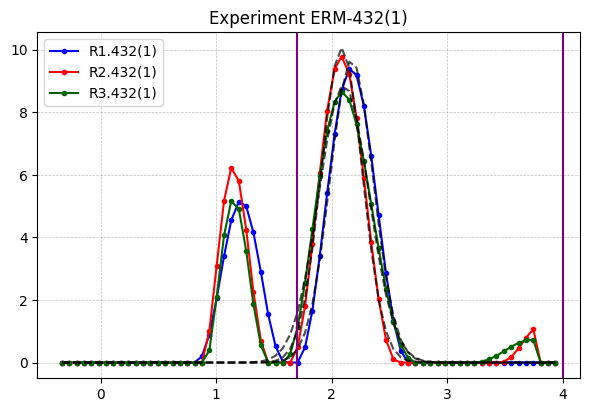

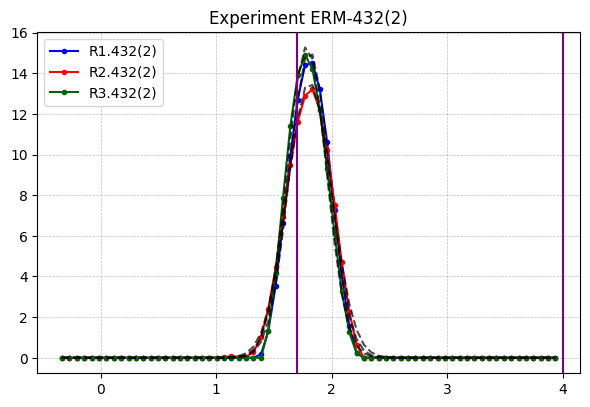

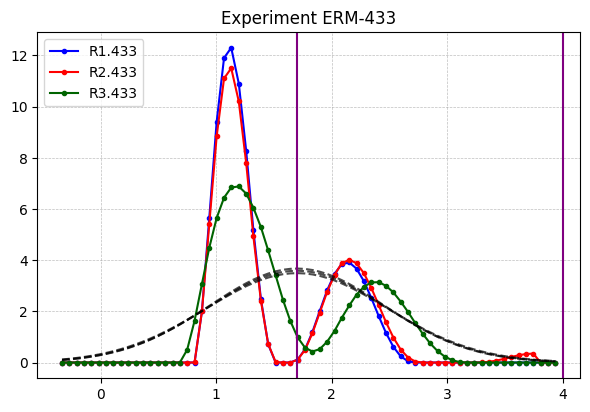

In [47]:
for exp in Design_Expert_Sampling_Round3.experiments:

    for rep in exp.replicas:
        if not hasattr(rep, "fitted_data"):
            rep.fit_data()

    log_x = exp.replicas[0].log_x_data

    y_all = np.array([rep.y_data for rep in exp.replicas])

    fit_all = np.vstack([rep.fitted_data for rep in exp.replicas])

    fig, ax = plot_(log_x, y_all, fit_all)

    #legend
    lines = ax.get_lines()

    n_rep = len(exp.replicas)
    
    for i in range(n_rep):
        lines[i].set_label(exp.replicas[i].name)

    ax.legend()

    mu_bounds = exp.replicas[0].mu_bounds
    ax.axvline(mu_bounds[0], c="purple")
    ax.axvline(mu_bounds[-1], c="purple")

    ax.set_title(f"Experiment {exp.name}")

    plt.show()

#### Replicates

True
-- Design Expert DLS Experiment --
NAME       : ERM-433
CODE       : ERM
NUMBER     : 433
REPLICAS   : 3
COLLECTION : Design_Expert_Sampling_Round3
DISTANCE : 21.1486

-- Design Expert DLS Replica --
NAME       : R1.433
CODE       : R1
NUMBER     : 433
DATA_LEN   : 68
DISTANCE   : 28.4111
EXPERIMENT : ERM-433
COLLECTION : Design_Expert_Sampling_Round3



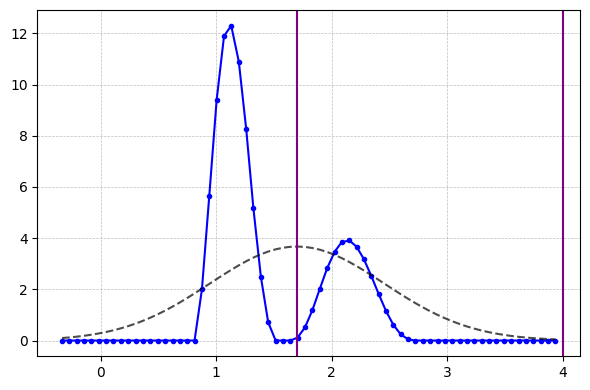

-- Design Expert DLS Replica --
NAME       : R2.433
CODE       : R2
NUMBER     : 433
DATA_LEN   : 68
DISTANCE   : 24.8428
EXPERIMENT : ERM-433
COLLECTION : Design_Expert_Sampling_Round3



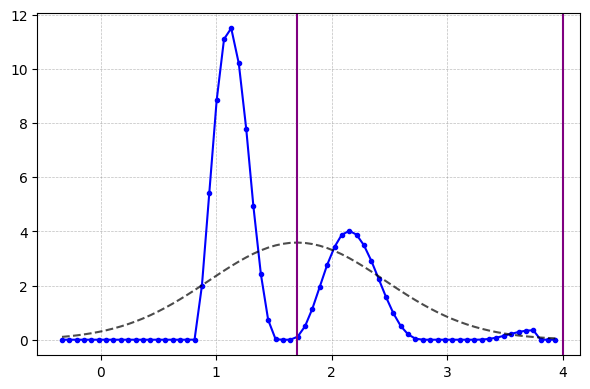

-- Design Expert DLS Replica --
NAME       : R3.433
CODE       : R3
NUMBER     : 433
DATA_LEN   : 68
DISTANCE   : 10.192
EXPERIMENT : ERM-433
COLLECTION : Design_Expert_Sampling_Round3



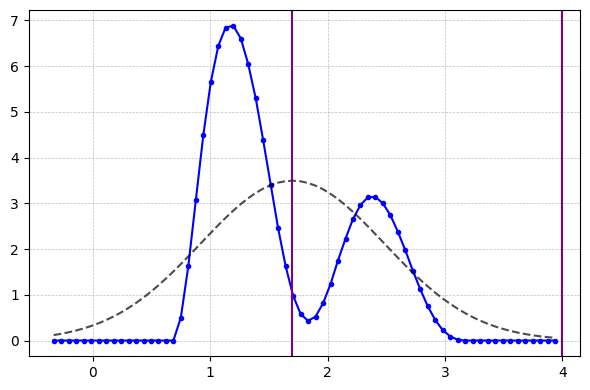

In [48]:
## Visual analysis
# A specific experiment is searched for and executed to generate a plot and see how the data behaves with respect to the ideal

found, debug_exp = Design_Expert_Sampling_Round3.find_experiment("ERM-433")
print(found)
print(debug_exp)

for rep in debug_exp.replicas:
    print(rep)
    rep.plot_fit()

In [ ]:
##Saves all the data (complete collection with information of the experiments and replicates) in a .npy file
#save_binary(Design_Expert_Sampling_Round3, "./Design_Expert_Sampling_Round3.npy")

##Loads the data from the .npy file and stores it in a variable if needed
#Design_Expert_Sampling_Round3_loaded = load_binary("./Design_Expert_Sampling_Round3.npy")
#print(Design_Expert_Sampling_Round3)